# Lecture 12 — Backtesting and Tactical Portfolio Construction
## Validating momentum strategies: walk-forward, CPCV, and the reality check

This self-contained notebook uses the bundled GAA teaching framework to illustrate,
on real data, that **every reported number flows through `backtesting.Backtester`**:

1. Two momentum rules as portfolio construction — **time-series** (single asset)
   and **cross-sectional long-only** (equal-weight tilt) — from
   `signals.stcma.momentum`, wired into the engine through a `ParameterGrid` and a
   `*_factory`.
2. **In-sample headline** — the over-fit number a naive grid search reports.
3. **Walk-forward analysis** — `WalkForwardStrategy` *is* a self-refitting
   `Strategy`, so one backtest = one honest out-of-sample path.
4. **Combinatorial purged cross-validation (CPCV)** — a *distribution* of OOS paths.
5. **Significance**: probabilistic / deflated Sharpe ratio and the
   stationary-bootstrap **reality check / SPA** over the backtested trial matrix.
6. A cross-section comparison across macro assets, US industries, and equity styles.

Data: monthly indexed performance from `data.perf_loader` (the bundled
`perf_M.parquet`). The reusable validation code lives in `signals/ml_pipeline/`;
this notebook drives the whole pipeline end-to-end.

In [ ]:
%matplotlib inline
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from backtesting import BacktestConfig, Backtester
from data.perf_loader import load_prices, load_returns, load_single_returns
from signals.stcma import (
    CrossSectionalMomentum,
    time_series_momentum_factory,
    cross_sectional_momentum_factory,
    time_series_momentum_returns,
)
from signals.ml_pipeline import (
    ParameterGrid,
    WalkForwardStrategy,
    backtest_param_cells,
    backtested_trial_matrix,
    select_best_param_cell,
    run_cpcv,
    whites_reality_check,
    hansens_spa,
)
from analytics.timeseries_analyzer import (
    probabilistic_sharpe_ratio_from_returns,
    deflated_sharpe_ratio_from_returns,
)
from taa.examples._validation_data import (
    sharpe,
    MACRO_ASSETS,
    US_INDUSTRIES,
    EQUITY_STYLES,
)

PPY = 12.0  # monthly data
LOOKBACKS_TS = [3, 6, 9, 12, 18, 24]
LOOKBACKS_XS = [3, 6, 9, 12]
QUANTILES = [0.1, 0.2, 0.3]

# Two engine configs: time-series momentum is a long/flat/short single-asset book;
# cross-sectional momentum is a long-only, fully-invested book.  Both rebalance
# monthly with 10 bps costs, and seed the first weights from the strategy.
TS_CONFIG = BacktestConfig(
    initial_capital=100.0, rebalance_freq="ME", long_short=True,
    initial_weights_from_strategy=True, transaction_cost_bps=10.0,
)
XS_CONFIG = BacktestConfig(
    initial_capital=100.0, rebalance_freq="ME", long_short=False,
    initial_weights_from_strategy=True, transaction_cost_bps=10.0,
)
pd.set_option("display.float_format", "{:.4f}".format)

# Slide figure pool.  The same `*_report.pdf` panels the example drivers in
# `taa/examples/` write are reproduced inline below and saved here, so the
# lecture deck `12-backtesting-taa.tex` can `\includegraphics` them.  Saving is
# guarded by the book/slides tree so the notebook runs unchanged in the
# standalone student repo (where the guard is False and figures only show inline).
FIG_DIR = REPO_ROOT / "book" / "slides" / "figures"

def save_fig(fig: "plt.Figure", name: str) -> None:
    """Save `fig` to the slide figure pool when running inside the book repo."""
    if FIG_DIR.parent.exists():
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / name, dpi=120, bbox_inches="tight")

## 1. Two momentum rules

**Time-series momentum** (single asset): the position is the *sign of the trailing
$L$-period return*, held over the next period —
$$ w_t = \operatorname{sign}\!\Big(\sum_{i=0}^{L-1} R_{t-i}\Big)\in\{-1,0,+1\},
   \qquad R^{\text{strat}}_{t+1}=w_t R_{t+1}. $$

The signal at $t$ uses only data through $t$ and applies to the *next* return, so it
is causal — perturbing a future return cannot change a past strategy return. This
causality is what lets a single full-sample backtest be reused (sliced) for every
train window and every CPCV test group.

In [2]:
eq = load_single_returns("EQ_US", frequency="M")
print(f"EQ_US monthly returns: {eq.index[0].date()} -> {eq.index[-1].date()} ({len(eq)} obs)")

# No-look-ahead check: bump a future return and confirm nothing earlier changes.
base = time_series_momentum_returns(eq, 12)
bumped = eq.copy(); bumped.iloc[200] += 0.5
after = time_series_momentum_returns(bumped, 12)
changed = (base != after) & ~(base.isna() & after.isna())
print("first changed observation:", int(np.argmax(changed.values)), "(== 200, none earlier)")
assert not changed.iloc[:200].any()

EQ_US monthly returns: 1970-01-31 -> 2025-12-31 (672 obs)
first changed observation: 200 (== 200, none earlier)


**Cross-sectional momentum** (long-only): rank assets by trailing $L$-period
return, then overlay a dollar-neutral *long-top / short-bottom* quantile tilt —
**equal-weighted within each leg** — onto a fully-invested $1/n$ book and scale it
to stay non-negative:
$$ w_{i,t}=\frac{1}{n}+\alpha\,o_{i,t},\qquad
   o_{i,t}=\begin{cases}+1/k & \text{top } k \text{ winners}\\[2pt]
                        -1/k & \text{bottom } k \text{ losers}\\[2pt]
                        0 & \text{otherwise,}\end{cases} $$
with $k=\lfloor \text{quantile}\cdot n\rfloor$ and $\alpha$ the largest factor
keeping every weight $\ge 0$ (the most-shorted name lands at exactly zero). The
result is genuinely long-only and fully invested ($\sum_i w_{i,t}=1$), which makes
the tilt directly comparable to an equal-weight benchmark.

In [3]:
macro_prices = load_prices(MACRO_ASSETS, frequency="M")
xs = CrossSectionalMomentum(lookback=12, quantile=0.3, long_only=True)  # equal-weighted legs
W_latest = xs.compute_weights(macro_prices, macro_prices.index[-1], None)
print("Most recent long-only momentum weights (equal-weight tilt toward winners):")
print(W_latest[W_latest > 0].sort_values(ascending=False).round(3))
print(f"sum = {W_latest.sum():.3f}   (fully invested, no shorts)")

Most recent long-only momentum weights (equal-weight tilt toward winners):
CO_GO-i      0.2000
EQ_EM-i      0.2000
EQ_EA-i      0.2000
EQ_US-i      0.1000
FI_HY_US-i   0.1000
FI_IG_US-i   0.1000
CO-i         0.1000
dtype: float64
sum = 1.000   (fully invested, no shorts)


## 2. In-sample headline and walk-forward analysis

The **Backtester is the walk-forward loop**: at each rebalance it calls
`strategy.compute_weights(data.loc[:as_of], as_of, ...)`, so any decision a strategy
makes from `data` is physically causal. `WalkForwardStrategy` exploits this — it
re-selects the best lookback on an expanding train window (via `.fit()` inside
`compute_weights`, on a yearly cadence) and delegates to that concrete strategy.
Running **one** backtest with it therefore produces the out-of-sample path.

The in-sample headline (pick the best lookback on the *whole* sample, then backtest
it) is the over-fit number a naive search reports. A shared `cell_returns` cache —
one full-sample backtest per grid cell — feeds the headline pick, the walk-forward
selection, and the data-snooping trials alike.

In [ ]:
prices = load_prices(["EQ_US"], frequency="M").reindex(eq.index).dropna()
GRID_TS = ParameterGrid(strategy={"lookback": LOOKBACKS_TS})

# One full-sample backtest per grid cell, reused by every scheme below.
cell_returns_ts = backtest_param_cells(GRID_TS, time_series_momentum_factory, prices, TS_CONFIG)
best_cell, _ = select_best_param_cell(
    GRID_TS, time_series_momentum_factory, prices, TS_CONFIG,
    periods_per_year=PPY, cell_returns=cell_returns_ts,
)
# Keep the in-sample NAV (not just the Sharpe): the optimism-vs-evidence report
# figure below overlays this curve on the walk-forward path.
is_bt = Backtester(TS_CONFIG).run(prices=prices, strategy=time_series_momentum_factory(best_cell))
is_sharpe = sharpe(is_bt.returns)

wfa_strategy = WalkForwardStrategy(
    time_series_momentum_factory, GRID_TS, TS_CONFIG,
    train_mode="expanding", min_train_size=60, retrain_every_rebalances=12,
    periods_per_year=PPY, cell_returns=cell_returns_ts,
)
wfa_bt = Backtester(TS_CONFIG).run(prices=prices, strategy=wfa_strategy)
wfa_oos = wfa_bt.returns.loc[wfa_strategy.first_fit_date_:]
wfa_sharpe = sharpe(wfa_oos)

print(f"in-sample best lookback = {best_cell.strategy['lookback']}, Sharpe (rf=0) = {is_sharpe:+.2f}")
print(f"{len(wfa_strategy.selected_params_)} refits; lookbacks chosen: "
      f"{sorted(wfa_strategy.selected_params_['lookback'].unique().tolist())}")
print(f"OOS annualised Sharpe (rf=0) = {wfa_sharpe:+.2f}")
print(f"OOS PSR(>0)                  = {probabilistic_sharpe_ratio_from_returns(wfa_oos):.3f}")

ax = (1 + wfa_oos.fillna(0)).cumprod().plot(figsize=(10, 4), linewidth=1.4)
ax.set_title("EQ_US time-series momentum — walk-forward OOS equity"); ax.set_yscale("log")
ax.set_ylabel("growth of 1"); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3. Combinatorial purged CV — a distribution of paths

`run_cpcv` takes the same `(factory, grid, prices, config)` as the rest of the
pipeline. It splits the timeline into $N$ groups, tests every combination of $k$,
purges and embargoes the training set, and recombines the predictions into
$\varphi=\binom{N-1}{k-1}$ full-length OOS paths. The Sharpe of each path is one
observation — turning the single walk-forward number into a distribution.

N=6, k=2 -> 15 splits, 5 paths
path Sharpe: mean=+0.41  std=0.04  min=+0.37  max=+0.44


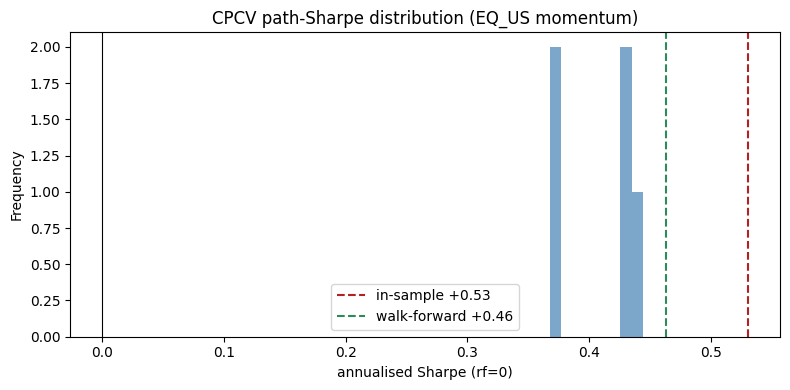

In [5]:
cpcv = run_cpcv(
    time_series_momentum_factory, GRID_TS, prices, TS_CONFIG,
    n_groups=6, n_test_groups=2, embargo_pct=0.02,
    label_horizon=max(LOOKBACKS_TS), periods_per_year=PPY,
)
print(f"N={cpcv.n_groups}, k={cpcv.n_test_groups} -> {cpcv.n_splits} splits, {cpcv.n_paths} paths")
print(f"path Sharpe: mean={cpcv.path_sharpes.mean():+.2f}  std={cpcv.path_sharpes.std():.2f}  "
      f"min={cpcv.path_sharpes.min():+.2f}  max={cpcv.path_sharpes.max():+.2f}")

ax = cpcv.path_sharpes.plot(kind="hist", bins=8, alpha=0.7, figsize=(8, 4), color="steelblue")
ax.axvline(is_sharpe, color="firebrick", ls="--", label=f"in-sample {is_sharpe:+.2f}")
ax.axvline(wfa_sharpe, color="seagreen", ls="--", label=f"walk-forward {wfa_sharpe:+.2f}")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("CPCV path-Sharpe distribution (EQ_US momentum)")
ax.set_xlabel("annualised Sharpe (rf=0)"); ax.legend(); plt.tight_layout(); plt.show()

## 4. Was the best trial luck?

- **Probabilistic Sharpe ratio (PSR)** — probability the true Sharpe beats a benchmark,
  with the Mertens correction for skew and kurtosis.
- **Deflated Sharpe ratio (DSR)** — PSR against the *expected maximum* Sharpe under the
  null, i.e. deflated for the number of trials.
- **Reality check / SPA** — bootstrap $p$-value that the best of the lookback grid beats
  a zero return, with serial dependence preserved by the stationary bootstrap.

The trials are each lookback's full-sample **backtested** returns —
`backtested_trial_matrix` slices the same `cell_returns` cache built above, so the
data-snooping tests see exactly the series the engine produced.

In [6]:
trials = backtested_trial_matrix(
    GRID_TS, time_series_momentum_factory, prices, TS_CONFIG, cell_returns=cell_returns_ts
)
rc = whites_reality_check(trials, n_resamples=2000, seed=7)
spa = hansens_spa(trials, n_resamples=2000, seed=7)
dsr = deflated_sharpe_ratio_from_returns(trials)
print(f"White reality check p-value = {rc.p_value:.3f}  (best trial: {rc.best_trial})")
print(f"Hansen SPA p-value          = {spa.p_value_consistent:.3f} "
      f"[{spa.p_value_lower:.3f}, {spa.p_value_upper:.3f}]")
print(f"Deflated Sharpe ratio       = {dsr:.3f}  (N={trials.shape[1]} trials)")
print("\nIn-sample optimism vs out-of-sample evidence:")
print(pd.Series({
    "in-sample best (full)": is_sharpe,
    "walk-forward OOS": wfa_sharpe,
    "CPCV path mean": cpcv.path_sharpes.mean(),
}).round(2))

White reality check p-value = 0.001  (best trial: lookback12)
Hansen SPA p-value          = 0.001 [0.001, 0.001]
Deflated Sharpe ratio       = 0.998  (N=6 trials)

In-sample optimism vs out-of-sample evidence:
in-sample best (full)   0.5300
walk-forward OOS        0.4600
CPCV path mean          0.4100
dtype: float64


### Report pictures: optimism vs. evidence, and a benchmark check

The two figures below are the lecture's *report pictures*, built from the same
backtested series used above and feeding the lecture slides:

1. **Optimism vs. evidence** — the in-sample equity curve sits *above* the honest
   walk-forward path, and the in-sample Sharpe is the optimistic upper tail of the
   CPCV path-Sharpe distribution.
2. **Benchmark check** — the walk-forward momentum book against a fixed
   12-month-lookback rule, buy-and-hold EQ_US, and MM_US_USD cash.

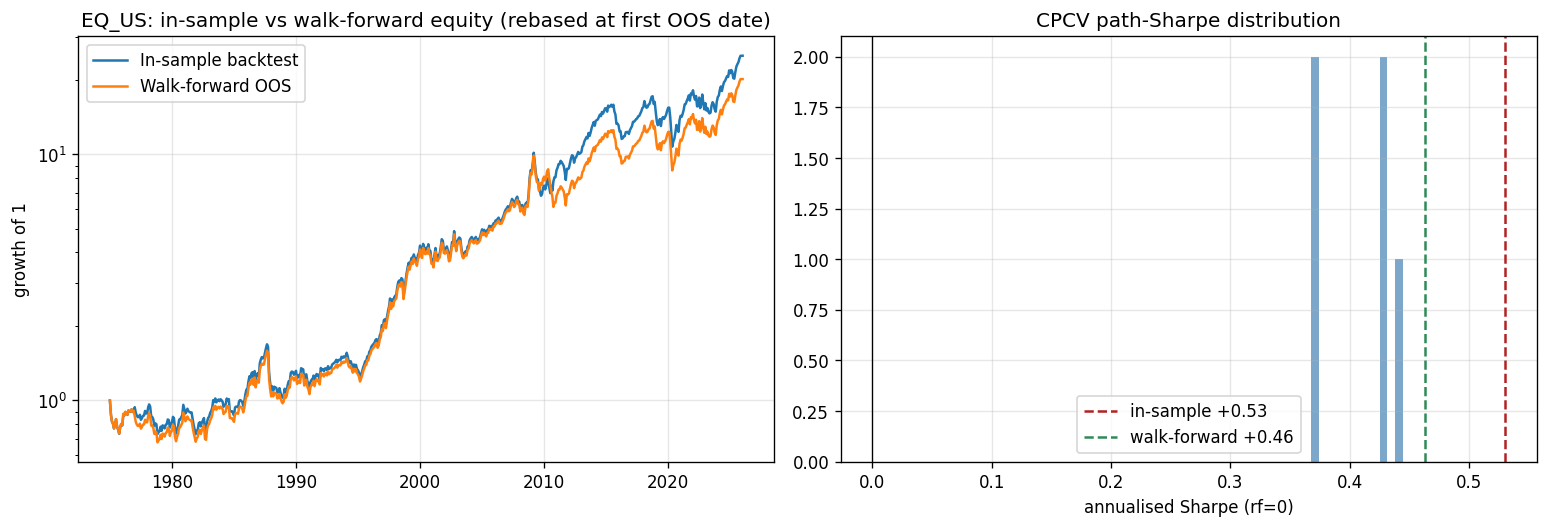

In [ ]:
# Report picture 1: optimism vs evidence (the `_plot` panel of
# taa/examples/validation_single_asset.py).  Left: the in-sample backtest curve
# sits above the walk-forward OOS path (both rebased to 1.0 at the first OOS
# date).  Right: the CPCV path-Sharpe distribution brackets the honest Sharpe;
# the in-sample value is its optimistic upper tail.
start = wfa_oos.dropna().index[0]
is_curve = is_bt.nav.loc[start:]; is_curve = is_curve / is_curve.iloc[0]
wfa_curve = (1.0 + wfa_oos.loc[start:].fillna(0.0)).cumprod()
wfa_curve = wfa_curve / wfa_curve.iloc[0]

fig, (ax_eq, ax_hist) = plt.subplots(1, 2, figsize=(13, 4.5))
ax_eq.plot(is_curve.index, is_curve, label="In-sample backtest")
ax_eq.plot(wfa_curve.index, wfa_curve, label="Walk-forward OOS")
ax_eq.set_title("EQ_US: in-sample vs walk-forward equity (rebased at first OOS date)")
ax_eq.set_yscale("log"); ax_eq.set_ylabel("growth of 1"); ax_eq.legend(); ax_eq.grid(alpha=0.3)

ax_hist.hist(cpcv.path_sharpes.dropna(), bins=12, alpha=0.7, color="steelblue")
ax_hist.axvline(is_sharpe, color="firebrick", ls="--", label=f"in-sample {is_sharpe:+.2f}")
ax_hist.axvline(wfa_sharpe, color="seagreen", ls="--", label=f"walk-forward {wfa_sharpe:+.2f}")
ax_hist.axvline(0.0, color="black", lw=0.8)
ax_hist.set_title("CPCV path-Sharpe distribution")
ax_hist.set_xlabel("annualised Sharpe (rf=0)"); ax_hist.legend(); ax_hist.grid(alpha=0.3)

fig.tight_layout(); save_fig(fig, "ch12_validation_single_asset.png"); plt.show()

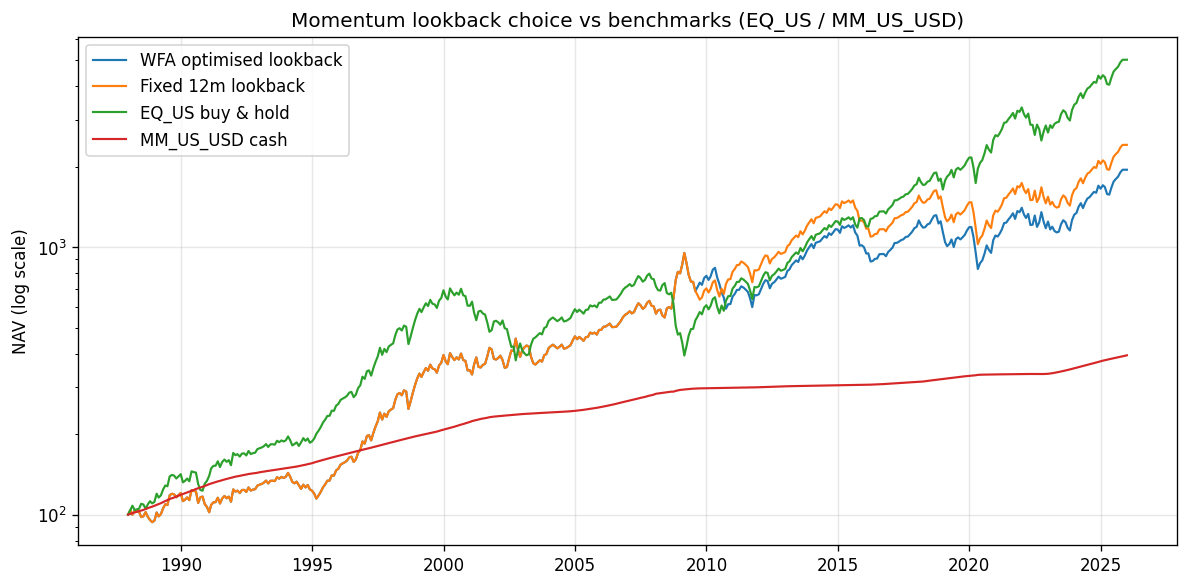

Final NAV (start = 100):
WFA optimised lookback   1948.5000
Fixed 12m lookback       2413.3000
EQ_US buy & hold         5022.6000
MM_US_USD cash            394.3000


In [ ]:
# Report picture 2: the walk-forward equity curve benchmarked against a fixed
# 12-month-lookback rule, buy-and-hold EQ_US, and MM_US_USD cash — the multi-
# allocation `*_benchmarks.pdf` the single-asset example writes, as one NAV chart.
FIXED_LB = 12
bench_prices = load_prices(["EQ_US", "MM_US_USD"], frequency="M").dropna(how="any")
fixed_returns = time_series_momentum_returns(eq, FIXED_LB)

# Common window where every series exists (MM_US_USD cash starts latest).
idx = (
    wfa_oos.dropna().index
    .intersection(fixed_returns.dropna().index)
    .intersection(bench_prices.index)
)

def _nav_from_returns(r: pd.Series) -> pd.Series:
    nav = (1.0 + r.reindex(idx).fillna(0.0)).cumprod()
    return nav / nav.iloc[0] * TS_CONFIG.initial_capital

def _buy_hold(column: str) -> pd.Series:
    price = bench_prices[column].reindex(idx)
    return price / price.iloc[0] * TS_CONFIG.initial_capital

nav_df = pd.DataFrame({
    "WFA optimised lookback": _nav_from_returns(wfa_oos),
    f"Fixed {FIXED_LB}m lookback": _nav_from_returns(fixed_returns),
    "EQ_US buy & hold": _buy_hold("EQ_US-i"),
    "MM_US_USD cash": _buy_hold("MM_US_USD-i"),
})

fig, ax = plt.subplots(figsize=(10, 5))
for col in nav_df.columns:
    ax.plot(nav_df.index, nav_df[col], linewidth=1.3, label=col)
ax.set_yscale("log")
ax.set_title("Momentum lookback choice vs benchmarks (EQ_US / MM_US_USD)")
ax.set_ylabel("NAV (log scale)"); ax.legend(loc="upper left"); ax.grid(alpha=0.3)
fig.tight_layout(); save_fig(fig, "ch12_validation_benchmarks.png"); plt.show()

print("Final NAV (start = 100):")
print(nav_df.iloc[-1].round(1).to_string())

## 5. Cross-section: long-only momentum vs. equal weight

The same toolkit applied to three cross-sections, all driven by
`cross_sectional_momentum_factory` and a `ParameterGrid` over lookback × quantile.
Long-only momentum is tested for **outperformance over equal weight** (does the
tilt beat naive diversification after the search?). A high *absolute* Sharpe is not
the same as beating the benchmark — so the reality check uses the equal-weight
return as its benchmark.

In [7]:
universes = {"Macro (10)": MACRO_ASSETS, "US industries (10)": US_INDUSTRIES,
             "Equity styles (9)": EQUITY_STYLES}
GRID_XS = ParameterGrid(
    strategy={"lookback": LOOKBACKS_XS, "quantile": QUANTILES, "long_only": [True]}
)
rows = {}
for name, assets in universes.items():
    R = load_returns(assets, frequency="M", balanced_panel=True)
    P = load_prices(assets, frequency="M").reindex(R.index).dropna()

    cr = backtest_param_cells(GRID_XS, cross_sectional_momentum_factory, P, XS_CONFIG)
    best, _ = select_best_param_cell(
        GRID_XS, cross_sectional_momentum_factory, P, XS_CONFIG,
        periods_per_year=PPY, cell_returns=cr,
    )
    is_sr = sharpe(Backtester(XS_CONFIG).run(prices=P, strategy=cross_sectional_momentum_factory(best)).returns)

    wf = WalkForwardStrategy(
        cross_sectional_momentum_factory, GRID_XS, XS_CONFIG,
        train_mode="expanding", min_train_size=48, retrain_every_rebalances=12,
        periods_per_year=PPY, cell_returns=cr,
    )
    wf_oos = Backtester(XS_CONFIG).run(prices=P, strategy=wf).returns.loc[wf.first_fit_date_:]

    cp = run_cpcv(cross_sectional_momentum_factory, GRID_XS, P, XS_CONFIG,
                  n_groups=6, n_test_groups=2, embargo_pct=0.02,
                  label_horizon=max(LOOKBACKS_XS), periods_per_year=PPY)

    tr = backtested_trial_matrix(GRID_XS, cross_sectional_momentum_factory, P, XS_CONFIG, cell_returns=cr)
    ew = R.mean(axis=1).reindex(tr.index)
    rc_u = whites_reality_check(tr, benchmark=ew, n_resamples=2000, seed=7)

    rows[name] = {"in-sample SR": is_sr, "WFA OOS SR": sharpe(wf_oos),
                  "CPCV mean SR": cp.path_sharpes.mean(), "RC p vs EW": rc_u.p_value}

summary = pd.DataFrame(rows).T
summary

,in-sample SR,WFA OOS SR,CPCV mean SR,RC p vs EW
Macro (10),1.1343,1.1007,1.1284,0.0035
US industries (10),0.8683,0.7027,0.8281,0.4723
Equity styles (9),0.9714,0.9770,0.9222,0.5367


**Reading the result.** All three universes show a healthy absolute Sharpe — long-only
momentum inherits the market premium — but only the macro cross-section *beats equal
weight* once the search is accounted for ($p\approx0.003$). The US-industry and
equity-style tilts have high standalone Sharpes yet do not separate from equal weight
($p\approx0.5$); the equity-style result also reflects a short, recent sample, so the
validation honestly reports low confidence rather than a flattering number.

### Takeaways
- Momentum rules are simple and parameterised, hence easy to over-fit.
- Walk-forward gives one honest path; CPCV gives the distribution around it.
- PSR/DSR and the bootstrap reality check turn *"looks good"* into a $p$-value.
- Treat the in-sample Sharpe as the optimistic upper bound, never the answer.